In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
#load datasets
df=pd.read_csv('/Users/temitope/Documents/Data_projects/covid19/owid-covid-data.csv')

In [3]:
#quick look at the data
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


In [4]:
#check shape of dataset
print('Shape:',df.shape)

Shape: (350108, 67)


In [5]:
#check columns 
print(df.columns.tolist())

['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hundred', 'total_

For our story we'll focus on these key columns:

location — country name,
continent — for regional analysis,
date — time series,
total_cases — cumulative cases,
new_cases — daily new cases,
total_deaths — cumulative deaths,
new_deaths — daily deaths,
people_vaccinated — vaccination progress,
people_fully_vaccinated — fully vaccinated,
gdp_per_capita — to compare rich vs poor countries,
population — for per capita calculations

In [6]:
#check for null values
print(df.isnull().sum())

iso_code                                        0
continent                                   16673
location                                        0
date                                            0
total_cases                                 38020
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       337924
excess_mortality_cumulative                337924
excess_mortality                           337924
excess_mortality_cumulative_per_million    337924
Length: 67, dtype: int64


In [7]:
#check data types
print(df.dtypes)

iso_code                                    object
continent                                   object
location                                    object
date                                        object
total_cases                                float64
                                            ...   
population                                 float64
excess_mortality_cumulative_absolute       float64
excess_mortality_cumulative                float64
excess_mortality                           float64
excess_mortality_cumulative_per_million    float64
Length: 67, dtype: object


In [8]:
df['date']=pd.to_datetime(df['date'])
print('Date range:',df['date'].min(),'to', df['date'].max())

Date range: 2020-01-01 00:00:00 to 2023-10-24 00:00:00


In [9]:
df[df['continent'].isna()]['location'].unique()
#During EDA I noticed the continent column had missing 
#values. I investigated by checking what locations had missing
#continents and discovered they were world and regional aggregates. 
#I removed them to avoid double counting in my country level analysis."
#These are world aggregate data that i do not need in the continent

array(['Africa', 'Asia', 'Europe', 'European Union', 'High income',
       'Low income', 'Lower middle income', 'North America', 'Oceania',
       'South America', 'Upper middle income', 'World'], dtype=object)

In [10]:
#Remove continent/world aggregate rows, keep only countries
df_countries=df[df['continent'].notna()]
print('The new shape after filtering:', df_countries.shape)

The new shape after filtering: (333435, 67)


In [11]:
#now, let us select only the columns we need
cols=['location', 'continent', 'date', 'total_cases', 'new_cases', 
        'total_deaths', 'new_deaths', 'people_vaccinated', 
        'people_fully_vaccinated', 'gdp_per_capita', 'population']
df_clean=df_countries[cols]
print('Clean dataset shape:',df_clean.shape)

Clean dataset shape: (333435, 11)


In [12]:
#let us check missing values again
df_clean.isnull().sum()

location                        0
continent                       0
date                            0
total_cases                 37749
new_cases                    9598
total_deaths                59186
new_deaths                   9544
people_vaccinated          269709
people_fully_vaccinated    272859
gdp_per_capita              63947
population                      0
dtype: int64

In [13]:
#let us fill the missing values with 0 since If a country has no recorded cases on a particular day → 0 cases
df_clean=df_clean.fillna(0)
print('Missing values after filling:')
print(df_clean.isnull().sum())

Missing values after filling:
location                   0
continent                  0
date                       0
total_cases                0
new_cases                  0
total_deaths               0
new_deaths                 0
people_vaccinated          0
people_fully_vaccinated    0
gdp_per_capita             0
population                 0
dtype: int64


In [14]:
df_clean.head()

,location,continent,date,total_cases,new_cases,total_deaths,new_deaths,people_vaccinated,people_fully_vaccinated,gdp_per_capita,population
0,Afghanistan,Asia,2020-01-03,0.0,0.0,0.0,0.0,0.0,0.0,1803.987,41128772.0
1,Afghanistan,Asia,2020-01-04,0.0,0.0,0.0,0.0,0.0,0.0,1803.987,41128772.0
2,Afghanistan,Asia,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,1803.987,41128772.0
3,Afghanistan,Asia,2020-01-06,0.0,0.0,0.0,0.0,0.0,0.0,1803.987,41128772.0
4,Afghanistan,Asia,2020-01-07,0.0,0.0,0.0,0.0,0.0,0.0,1803.987,41128772.0


In [15]:
#Get latest data per country
# Get the most recent record for each country
# This gives us the final cumulative totals per country
df_latest=df_clean.groupby('location').last().reset_index()
print('Number of countries:', len(df_latest))


Number of countries: 243


In [16]:
#Top 10 countries by total cases
top10_cases=df_latest.nlargest(10,'total_cases')[['location','total_cases']]
print(top10_cases)

           location  total_cases
229   United States  103436829.0
42            China   99315684.0
72           France   38997490.0
78          Germany   38437756.0
28           Brazil   37721749.0
202     South Korea   34571873.0
105           Japan   33803572.0
228  United Kingdom   24779150.0
177          Russia   23061960.0
221          Turkey   17004677.0


/var/folders/vw/rynbknvs76n1g1w8qk2qy3dc0000gn/T/ipykernel_57181/340316790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_cases,x='total_cases',y='location',palette = 'Reds_r')


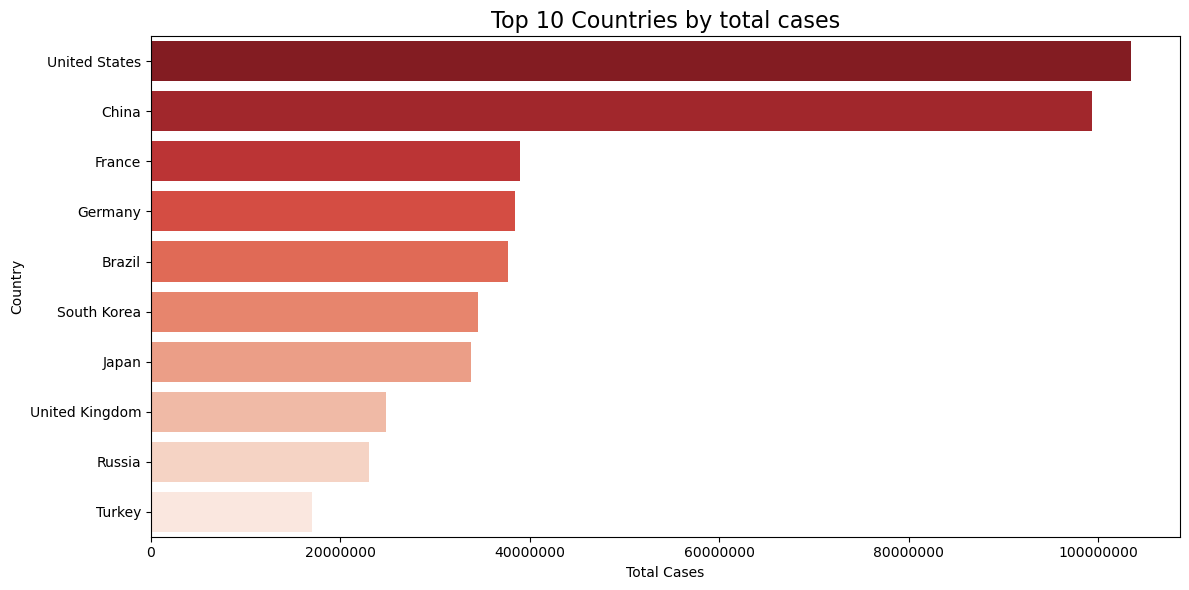

In [17]:
#visualization of above data(Top 10 countries by total cases)
plt.figure(figsize=(12,6))
sns.barplot(data=top10_cases,x='total_cases',y='location',palette = 'Reds_r')
plt.title('Top 10 Countries by total cases', fontsize=16)
plt.xlabel('Total Cases')
plt.ylabel('Country')
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()


In [18]:
#let us get Top 10 countries by death
top10_deaths=df_latest.nlargest(10,'total_deaths')[['location','total_deaths']]
print(top10_deaths)

           location  total_deaths
229   United States     1136920.0
28           Brazil      704659.0
177          Russia      400102.0
135          Mexico      334699.0
228  United Kingdom      230383.0
168            Peru      221704.0
78          Germany      174979.0
72           France      167985.0
97        Indonesia      161918.0
98             Iran      146480.0


/var/folders/vw/rynbknvs76n1g1w8qk2qy3dc0000gn/T/ipykernel_57181/768105872.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_deaths,x='total_deaths',y='location',palette='Blues_r')


<function matplotlib.pyplot.show(close=None, block=None)>

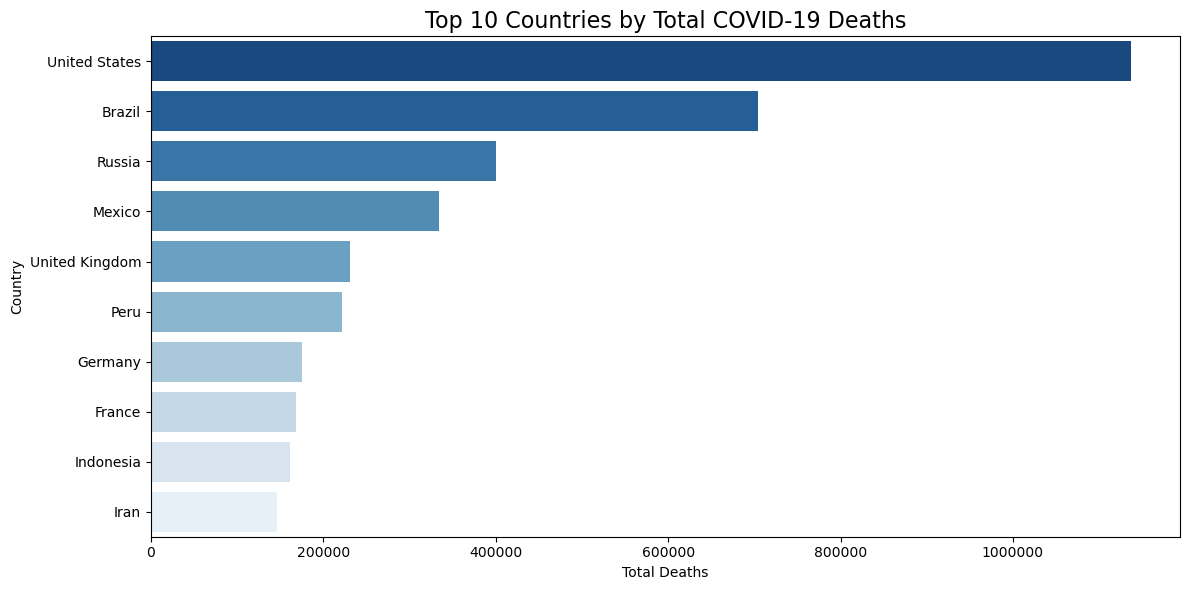

In [19]:
#let's create a bar chart for the Top 10 deaths
plt.figure(figsize=(12,6))
sns.barplot(data=top10_deaths,x='total_deaths',y='location',palette='Blues_r')
plt.title('Top 10 Countries by Total COVID-19 Deaths', fontsize=16)
plt.xlabel('Total Deaths')
plt.ylabel('Country')
plt.ticklabel_format(style='plain',axis='x')
plt.tight_layout()
plt.show


I noticed china wasn't inlcuded in the top 10 deaths, i would lean towards it being likely a combination of strict policies early on and underreporting since China has strong healtcare system and they control the news going in and out of the country.


In [20]:
#Global daily cases
#df_global=df_latest.groupby('date')['new_cases'].sum().reset_index()
#print(df_global.head())
#when i ran the above code the dates weren't orderly, so i had to clean the data here for the date again.
# Sort the clean dataset by date before grouping
df_clean=df_clean.sort_values('date')
# Group by date and sum new cases globally
df_global=df_clean.groupby('date')['new_cases'].sum().reset_index()
print(df_global.head())

        date  new_cases
0 2020-01-01        0.0
1 2020-01-02        0.0
2 2020-01-03        0.0
3 2020-01-04        3.0
4 2020-01-05        0.0


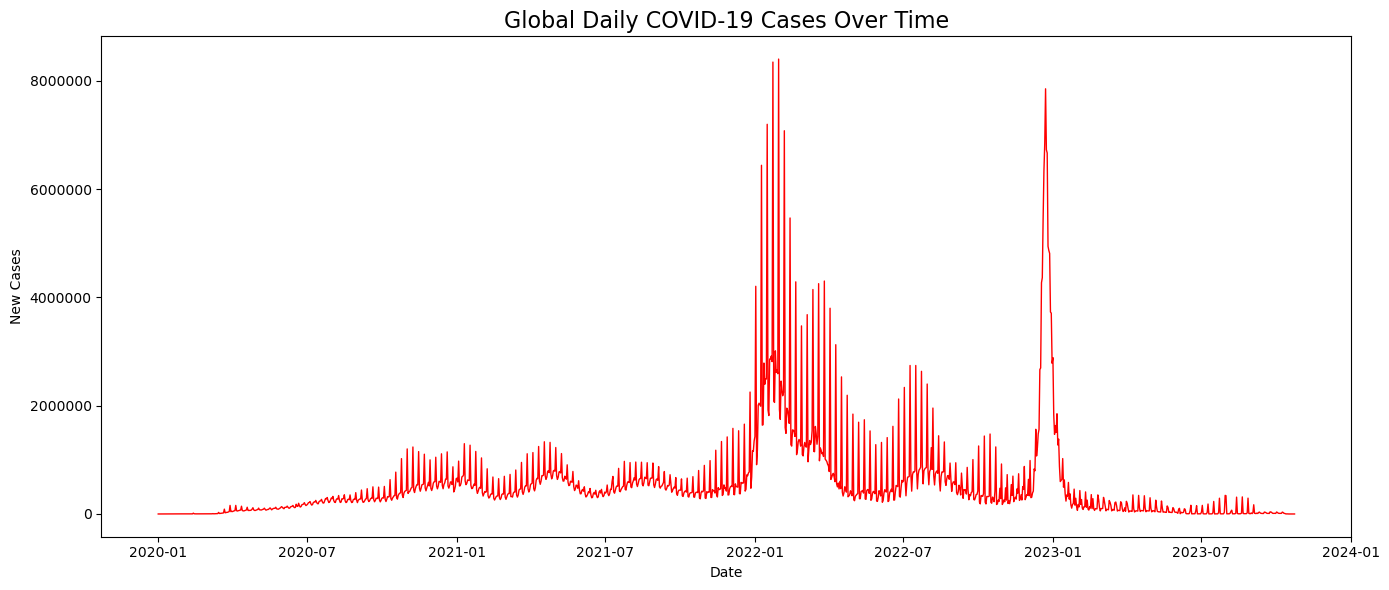

In [21]:
#Plot Global daily cases
plt.figure(figsize=(14,6))
plt.plot(df_global['date'],df_global['new_cases'], color='red',linewidth=1)
plt.title('Global Daily COVID-19 Cases Over Time',fontsize=16)
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()

In [22]:
#Global vacination data
# Group by date and sum vaccinations globally over time
df_vacc=df_clean.groupby('date')['people_vaccinated'].sum().reset_index()
print(df_vacc.head())

        date  people_vaccinated
0 2020-01-01                0.0
1 2020-01-02                0.0
2 2020-01-03                0.0
3 2020-01-04                0.0
4 2020-01-05                0.0


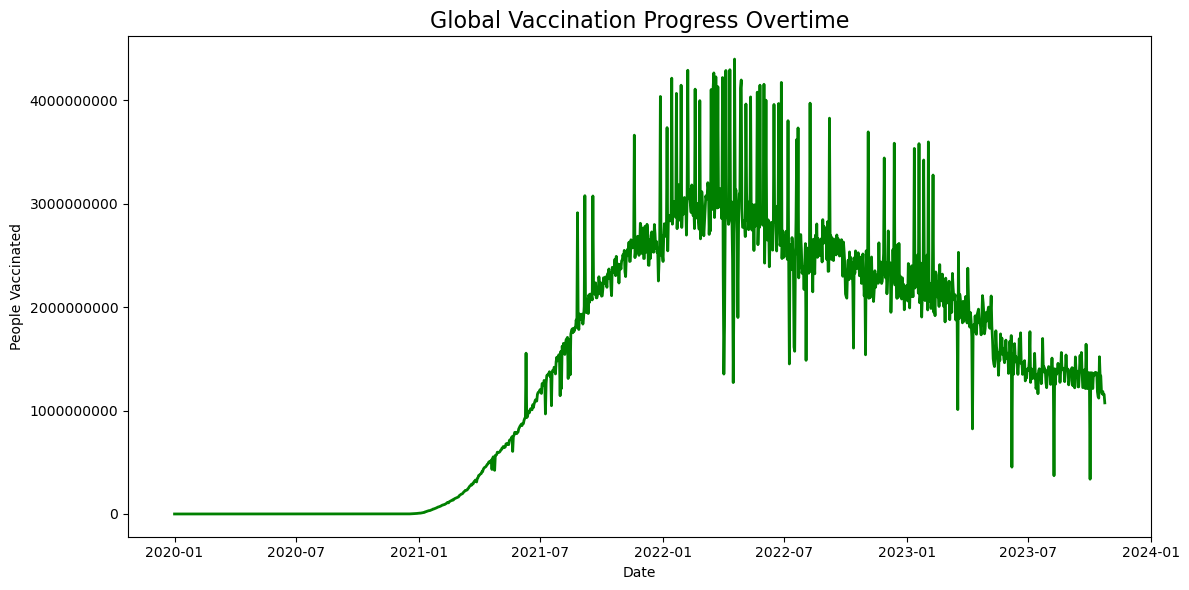

In [23]:
#let's plot vaccination progress
plt.figure(figsize=(12,6))
plt.plot(df_vacc['date'],df_vacc['people_vaccinated'],color='green',linewidth=2)
plt.title('Global Vaccination Progress Overtime', fontsize=16)
plt.xlabel('Date')
plt.ylabel('People Vaccinated')
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()

In [26]:
#Now let's compare GDP vs Death Rate to see if richer countries fared better.

#Calculate death rate as total death deaths per total cases
df_latest['death_rate']= (df_latest['total_deaths']/df_latest['total_cases']) * 100

#Remove rows where death rate or gdp is 0
df_gdp=df_latest[(df_latest['gdp_per_capita']>0) & (df_latest['death_rate'] > 0)]

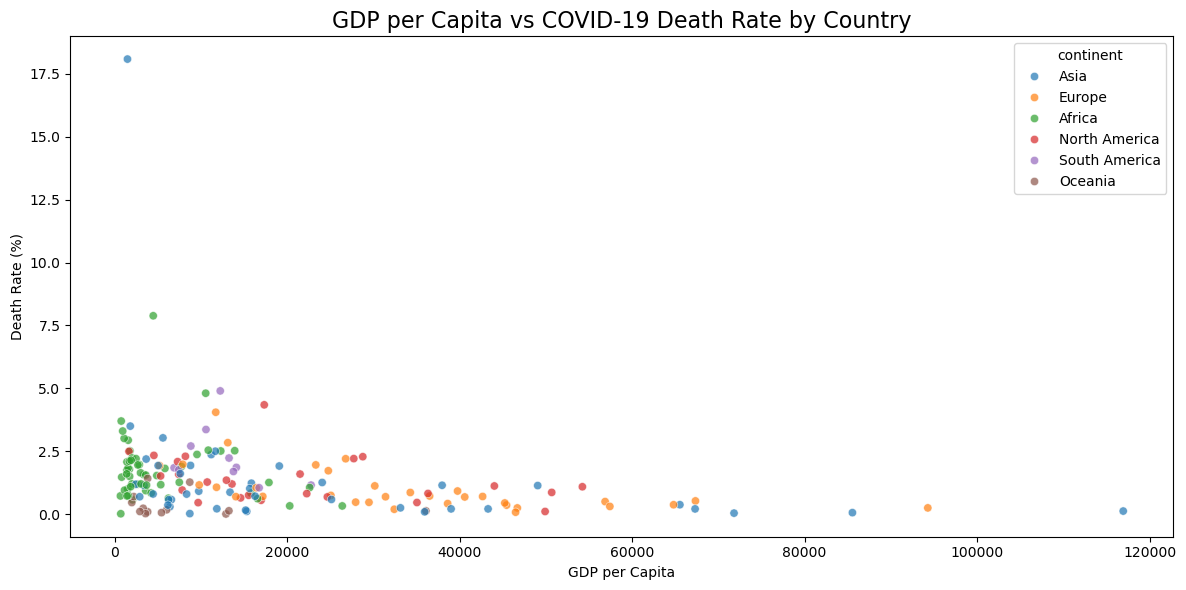

In [28]:
#now let's plot
#scatter plot of GDP per capita vs death rate
plt.figure(figsize=(12,6))
sns.scatterplot(data=df_gdp,x='gdp_per_capita',y='death_rate',hue='continent',alpha=0.7)
plt.title('GDP per Capita vs COVID-19 Death Rate by Country', fontsize=16)
plt.xlabel('GDP per Capita')
plt.ylabel('Death Rate (%)')
plt.tight_layout()
plt.show()

## Key Insights from the COVID-19 Global Analysis

### 1. The United States was hit hardest overall
The USA led both total cases (103 million) and total deaths (1.1 million) — 
significantly ahead of every other country. Brazil came second in deaths 
with 704,000 despite having far fewer cases than China.

### 2. China's numbers raise questions
China recorded 99 million cases — second highest globally — yet didn't 
appear in the top 10 deaths. This is likely a combination of strict early 
lockdowns, a strong healthcare system, and underreporting. China's 
government controls information flow which makes independent verification 
difficult.

### 3. COVID-19 came in waves
The global daily cases chart clearly shows multiple waves across 2020-2023. 
The largest peak occurred in early 2022 driven by the highly transmissible 
Omicron variant before cases gradually declined through 2023.

### 4. Vaccination rollout was rapid once it started
Zero vaccinations existed before late 2020. Once vaccines were approved, 
the global rollout accelerated sharply through 2021 reaching billions of 
people — one of the fastest mass vaccination campaigns in human history.

### 5. Wealth alone didn't determine outcomes
The GDP vs death rate scatter plot shows no clear relationship between 
a country's wealth and its COVID-19 death rate. Factors like population 
age, government response, healthcare capacity and reporting accuracy all 
played significant roles alongside economic strength.

### Final Thought
This analysis reminded me that data never tells the complete story. 
Behind every number is a government policy, a healthcare decision, 
or a reporting choice that shapes what we see. The best a data scientist 
can do is ask the right questions and let the data guide — not decide — 
the conclusions.